In [18]:
import pandas as pd
import numpy as np
import statistics

In [19]:
df = pd.read_csv('metadados_completos_sol_sbc_portugues_2020_2025 - Métricas Linguísticas.csv')

In [ ]:
df.info()

In [ ]:
df.head()

Medidas Estatísticas Descritivas 

In [20]:
list_metrics = df.columns.tolist()[15:]

df_metrics = pd.DataFrame(columns=['Métrica', 'n', 'Ano', 'Média', 'Mediana', 'Desvio Padrão'])

for metric in list_metrics:
    for year in range(2020, 2026):
        subset = df[df['Year'] == year]
        mean_value = subset[metric].mean()
        n = len(subset[metric])
        median_value = statistics.median(subset[metric].dropna())
        std_value = subset[metric].std()
        df_metrics = pd.concat([
            df_metrics,
            pd.DataFrame({
                'Métrica': [metric],
                'n': [n],
                'Ano': [year],
                'Média': [mean_value],
                'Mediana': [median_value],
                'Desvio Padrão': [std_value]  
            })
        ], ignore_index=True)

df_metrics.head(6)

C:\Users\05646078199\AppData\Local\Temp\ipykernel_3888\1888009323.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_metrics = pd.concat([


,Métrica,n,Ano,Média,Mediana,Desvio Padrão
0,adjective_ratio,962,2020,0.072000,0.07080,0.029075
1,adjective_ratio,1456,2021,0.074785,0.07258,0.030715
2,adjective_ratio,1262,2022,0.071944,0.07003,0.030017
3,adjective_ratio,1796,2023,0.073003,0.07143,0.029486
4,adjective_ratio,2447,2024,0.073316,0.07207,0.033841
5,adjective_ratio,2143,2025,0.085335,0.08434,0.033463


T-test Welch

In [21]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [24]:
df = df_metrics.copy()

baseline_years = [2020, 2021, 2022]


baseline_results = []


for metric in df['Métrica'].unique():
    df_metric = df[df['Métrica'] == metric]
    
    
    df_base = df_metric[df_metric['Ano'].isin(baseline_years)]
    
    
    n1 = df_base['n'].sum()
    
    
    s1_squared = np.sum((df_base['n'] - 1) * df_base['Desvio Padrão']**2) / (n1 - len(df_base))
    
    
    x1 = np.average(df_base['Média'], weights=df_base['n'])
    
    # Armazena resultado
    baseline_results.append({
        'Métrica': metric,
        'n_baseline': n1,
        'Média_baseline': x1,
        'Variância_baseline': s1_squared,
        'DP_baseline': np.sqrt(s1_squared)
    })

# Converte para DataFrame
df_baseline = pd.DataFrame(baseline_results)

df_baseline.head()

,Métrica,n_baseline,Média_baseline,Variância_baseline,DP_baseline
0,adjective_ratio,3680,0.073082,0.000903,0.030054
1,adverbs,3680,0.018017,0.000258,0.016048
2,content_words,3680,0.592842,0.001442,0.037979
3,flesch,3680,10.135474,221.515635,14.883401
4,function_words,3680,0.407158,0.001442,0.037979


In [44]:
df = df_metrics.copy()

# Definindo os anos pós-baseline
post_years = [2023, 2024, 2025]

# Inicializa lista para resultados do t-test
results = []

for metric in df['Métrica'].unique():
    # Busca baseline calculado
    base = df_baseline[df_baseline['Métrica'] == metric].iloc[0]
    x1 = base['Média_baseline']
    s1_squared = base['Variância_baseline']
    n1 = base['n_baseline']
    
    # Dados da métrica para anos pós-baseline
    df_metric_post = df[(df['Métrica'] == metric) & (df['Ano'].isin(post_years))]
    
    for idx, row in df_metric_post.iterrows():
        x2 = row['Média']
        s2_squared = row['Desvio Padrão']**2
        n2 = row['n']
        
        # Evita zero na variância
        s1_squared = max(s1_squared, 1e-10)
        s2_squared = max(s2_squared, 1e-10)
        n1_safe = max(n1, 2)
        n2_safe = max(n2, 2)
        
        # Erro padrão
        SE = np.sqrt(s1_squared / n1_safe + s2_squared / n2_safe)
        
        # t-statistic
        t_stat = (x1 - x2) / SE
        
        # Graus de liberdade aproximado de Welch
        numerator = (s1_squared/n1_safe + s2_squared/n2_safe)**2
        denominator = (s1_squared/n1_safe)**2 / (n1_safe - 1) + (s2_squared/n2_safe)**2 / (n2_safe - 1)
        df_welch = numerator / denominator if denominator != 0 else np.nan
        
        # p-value (t bilateral)
        if not np.isnan(df_welch):
            p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=df_welch))
        else:
            # aproximação normal se df inválido
            p_val = 2 * (1 - stats.norm.cdf(abs(t_stat)))
        
        # Diferença e interpretação
        diff = x2 - x1
        signif = "Altamente significativo" if p_val < 0.001 else ("Significativo" if p_val < 0.05 else "Não significativo")
        direction = "Aumento" if diff > 0 else ("Diminuição" if diff < 0 else "-")
        
        results.append({
            'Métrica': metric,
            'Ano': row['Ano'],
            'X1': x1,
            'n1': n1,
            's1_squared': s1_squared,
            'X2': x2,
            'n2': n2,
            's2_squared': s2_squared,
            'Diferença média': diff,
            't': t_stat,
            'p-value': p_val,
            'Significância': signif,
            'Direção': direction
        })

# Converte para DataFrame
df_results = pd.DataFrame(results)
df_results.head(10)
df_results.to_csv('analise_t_test_metricas_linguisticas.csv', index=False)


Análise dos Resultados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
df_results = pd.read_csv('analise_t_test_metricas_linguisticas - Grupos Linguísticos.csv')
df_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Grupo Linguístico  216 non-null    object 
 1   Métrica            216 non-null    object 
 2   Ano                216 non-null    int64  
 3   X1                 216 non-null    float64
 4   n1                 216 non-null    int64  
 5   s1_squared         216 non-null    float64
 6   X2                 216 non-null    float64
 7   n2                 216 non-null    int64  
 8   s2_squared         216 non-null    float64
 9   Diferença média    216 non-null    float64
 10  t                  216 non-null    float64
 11  p-value            216 non-null    float64
 12  Significância      216 non-null    object 
 13  Direção            216 non-null    object 
dtypes: float64(7), int64(3), object(4)
memory usage: 23.8+ KB


In [14]:
df_results.groupby('Ano')['Significância'].value_counts()

Ano   Significância          
2023  Não significativo          43
      Altamente significativo    16
      Significativo              13
2024  Altamente significativo    47
      Não significativo          15
      Significativo              10
2025  Altamente significativo    45
      Não significativo          20
      Significativo               7
Name: count, dtype: int64

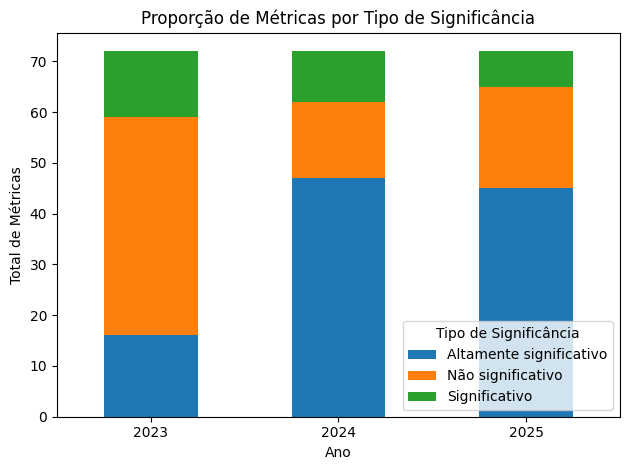

In [13]:
total = (
    df_results
    .groupby(['Ano', 'Significância'])
    .size()
    .reset_index(name='Total')
)

# Pivot
pivot_df = total.pivot(index='Ano', columns='Significância', values='Total')

# Plot stacked bar
pivot_df.plot(kind="bar", stacked=True)

plt.title("Proporção de Métricas por Tipo de Significância")
plt.xlabel("Ano")
plt.ylabel("Total de Métricas")
plt.legend(title="Tipo de Significância")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [ ]:
df_results.groupby('Ano')['Direção'].value_counts()

Ano   Direção   
2023  Diminuição    37
      Aumento       32
      -              3
2024  Diminuição    41
      Aumento       28
      -              3
2025  Diminuição    40
      Aumento       29
      -              3
Name: count, dtype: int64

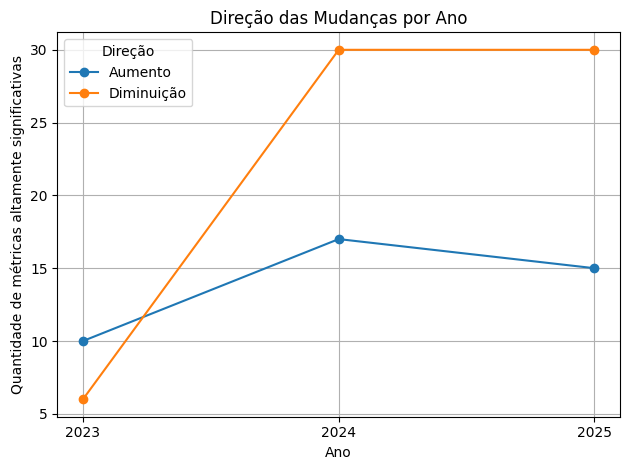

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# filtrar somente Altamente significativo
df_sig = df_results[df_results["Significância"] == "Altamente significativo"]

# agrupar apenas por Ano e Direção
grouped = (
    df_sig.groupby(["Ano", "Direção"])
    .size()
    .reset_index(name="Quantidade")
)

# pivot para formato Ano x Direção
pivot = grouped.pivot(index="Ano", columns="Direção", values="Quantidade").fillna(0)

# garantir ordem correta dos anos
pivot = pivot.reindex([2023, 2024, 2025])

# plot em linhas
pivot.plot(kind="line", marker="o")

plt.title("Direção das Mudanças por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de métricas altamente significativas")
plt.xticks([2023, 2024, 2025])
plt.legend(title="Direção")
plt.grid(True)

plt.tight_layout()
plt.show()
